<a href="https://colab.research.google.com/github/Jyothidatla25/JYOTHIRMAI_INFO-5731/blob/main/INFO5731_Assignment_3_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


In [1]:
!pip install gensim pyLDAvis nltk scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 88.1 MB/s eta 0:00:00


In [2]:
import random
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
data = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
documents = data.data

random.seed(42)
sample_docs = random.sample(documents, 2000)

print("Number of selected documents:", len(sample_docs))

Number of selected documents: 2000


In [4]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

processed_docs = [preprocess_text(doc) for doc in sample_docs]
processed_docs[:2]

[['general',
  'question',
  'readers',
  'extensive',
  'playoff',
  'coverage',
  'canada',
  'almost',
  'impossible',
  'watch',
  'series',
  'two',
  'series',
  'opportunity',
  'watch',
  'year',
  'wash',
  'nyi',
  'chi',
  'stl',
  'latter',
  'wrong',
  'time',
  'zone',
  'canada',
  'basically',
  'swamped',
  'coverage',
  'wonder',
  'many',
  'series',
  'games',
  'televised',
  'nationally',
  'even',
  'locally',
  'much',
  'precedence',
  'take',
  'say',
  'local',
  'news',
  'games',
  'double',
  'email',
  'waste',
  'bandwidth',
  'please',
  'news',
  'feed',
  'kind',
  'slow',
  'anyways'],
 ['think',
  'kind',
  'comparison',
  'pretty',
  'useless',
  'general',
  'processor',
  'good',
  'good',
  'computer',
  'designed',
  'around',
  'adn',
  'computer',
  'used',
  'designed',
  'purpose',
  'comparing',
  'processor',
  'speed',
  'pretty',
  'dumb',
  'increase',
  'clock',
  'speed',
  'increase',
  'speed',
  'among',
  'things',
  'mean',
  's

In [6]:
dictionary = corpora.Dictionary(processed_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print("Number of documents in corpus:", len(corpus))
print("Number of unique tokens:", len(dictionary))

Number of documents in corpus: 2000
Number of unique tokens: 4785


In [7]:
lda_model_10 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    alpha='auto'
)

lda_topics_10 = lda_model_10.print_topics(num_words=10)
for topic in lda_topics_10:
    print(topic)

(0, '0.011*"would" + 0.009*"like" + 0.008*"one" + 0.006*"keyboard" + 0.006*"israel" + 0.005*"right" + 0.005*"want" + 0.005*"get" + 0.005*"think" + 0.004*"please"')
(1, '0.171*"max" + 0.011*"drive" + 0.010*"good" + 0.009*"disk" + 0.007*"one" + 0.007*"get" + 0.006*"know" + 0.005*"thanks" + 0.005*"system" + 0.005*"files"')
(2, '0.011*"one" + 0.009*"people" + 0.007*"like" + 0.007*"said" + 0.007*"would" + 0.007*"time" + 0.006*"get" + 0.006*"got" + 0.005*"back" + 0.005*"year"')
(3, '0.011*"com" + 0.010*"window" + 0.009*"edu" + 0.008*"available" + 0.008*"get" + 0.007*"motif" + 0.007*"information" + 0.006*"use" + 0.006*"windows" + 0.006*"server"')
(4, '0.007*"also" + 0.007*"would" + 0.006*"ground" + 0.004*"data" + 0.004*"information" + 0.004*"good" + 0.004*"space" + 0.004*"two" + 0.004*"get" + 0.003*"may"')
(5, '0.009*"one" + 0.008*"people" + 0.007*"would" + 0.006*"may" + 0.005*"entry" + 0.005*"well" + 0.005*"like" + 0.005*"even" + 0.005*"get" + 0.005*"water"')
(6, '0.012*"space" + 0.007*"new"

In [8]:
lda_coherence_10 = CoherenceModel(
    model=lda_model_10,
    texts=processed_docs,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print("LDA Coherence Score for K=10:", lda_coherence_10)

LDA Coherence Score for K=10: 0.4256551379305297


In [9]:
texts_joined = [" ".join(doc) for doc in processed_docs]

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts_joined)

terms = tfidf_vectorizer.get_feature_names_out()

In [10]:
lsa_model_10 = TruncatedSVD(n_components=10, random_state=42)
lsa_model_10.fit(tfidf_matrix)

for i, comp in enumerate(lsa_model_10.components_):
    terms_in_topic = [terms[idx] for idx in comp.argsort()[-10:][::-1]]
    print(f"Topic {i}: {terms_in_topic}")

Topic 0: ['would', 'one', 'like', 'people', 'know', 'get', 'think', 'also', 'use', 'time']
Topic 1: ['thanks', 'windows', 'please', 'anyone', 'mail', 'advance', 'files', 'use', 'using', 'file']
Topic 2: ['god', 'anyone', 'thanks', 'know', 'please', 'jesus', 'church', 'advance', 'mail', 'bible']
Topic 3: ['use', 'windows', 'files', 'dos', 'system', 'file', 'key', 'god', 'using', 'problem']
Topic 4: ['would', 'government', 'encryption', 'law', 'key', 'use', 'like', 'information', 'israel', 'chip']
Topic 5: ['would', 'like', 'anyone', 'know', 'windows', 'think', 'get', 'game', 'problem', 'monitor']
Topic 6: ['new', 'drive', 'god', 'like', 'would', 'car', 'disk', 'drives', 'sale', 'get']
Topic 7: ['like', 'com', 'edu', 'get', 'would', 'article', 'pitt', 'soon', 'please', 'look']
Topic 8: ['would', 'files', 'new', 'god', 'year', 'also', 'game', 'windows', 'use', 'team']
Topic 9: ['edu', 'people', 'pitt', 'like', 'new', 'soon', 'files', 'windows', 'government', 'think']


In [11]:
lsa_topics_words_10 = []

for comp in lsa_model_10.components_:
    topic_words = [terms[idx] for idx in comp.argsort()[-10:][::-1]]
    lsa_topics_words_10.append(topic_words)

lsa_coherence_10 = CoherenceModel(
    topics=lsa_topics_words_10,
    texts=processed_docs,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print("LSA Coherence Score for K=10:", lsa_coherence_10)

LSA Coherence Score for K=10: 0.38216648785073365


In [12]:
k_values = [5, 10, 15, 20]
lda_scores = []
lsa_scores = []

In [13]:
for k in k_values:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )

    coherence = CoherenceModel(
        model=lda_model,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()

    lda_scores.append(coherence)
    print(f"LDA Coherence Score for K={k}: {coherence}")

LDA Coherence Score for K=5: 0.40998248976411655
LDA Coherence Score for K=10: 0.4256551379305297
LDA Coherence Score for K=15: 0.41178810316388076
LDA Coherence Score for K=20: 0.4078187188666482


In [14]:
for k in k_values:
    lsa_model = TruncatedSVD(n_components=k, random_state=42)
    lsa_model.fit(tfidf_matrix)

    lsa_topic_words = []
    for comp in lsa_model.components_:
        words = [terms[idx] for idx in comp.argsort()[-10:][::-1]]
        lsa_topic_words.append(words)

    coherence = CoherenceModel(
        topics=lsa_topic_words,
        texts=processed_docs,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence()

    lsa_scores.append(coherence)
    print(f"LSA Coherence Score for K={k}: {coherence}")

LSA Coherence Score for K=5: 0.4516061813405943
LSA Coherence Score for K=10: 0.38216648785073365
LSA Coherence Score for K=15: 0.370404826584142
LSA Coherence Score for K=20: 0.358356435757714


In [15]:
best_lda_k = k_values[np.argmax(lda_scores)]
best_lsa_k = k_values[np.argmax(lsa_scores)]

print("Optimal K for LDA:", best_lda_k)
print("Optimal K for LSA:", best_lsa_k)

Optimal K for LDA: 10
Optimal K for LSA: 5


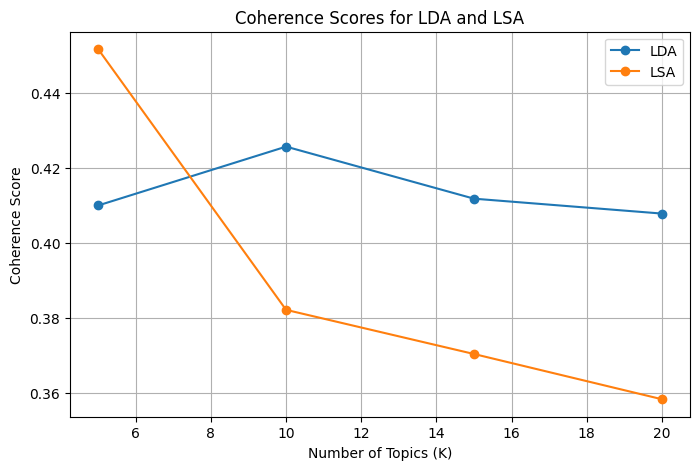

In [16]:
plt.figure(figsize=(8,5))
plt.plot(k_values, lda_scores, marker='o', label='LDA')
plt.plot(k_values, lsa_scores, marker='o', label='LSA')
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence Score")
plt.title("Coherence Scores for LDA and LSA")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_lda_k,
    random_state=42,
    passes=10,
    alpha='auto'
)

print("Final LDA Topics:")
for topic in final_lda_model.print_topics(num_words=10):
    print(topic)

Final LDA Topics:
(0, '0.011*"would" + 0.009*"like" + 0.008*"one" + 0.006*"keyboard" + 0.006*"israel" + 0.005*"right" + 0.005*"want" + 0.005*"get" + 0.005*"think" + 0.004*"please"')
(1, '0.171*"max" + 0.011*"drive" + 0.010*"good" + 0.009*"disk" + 0.007*"one" + 0.007*"get" + 0.006*"know" + 0.005*"thanks" + 0.005*"system" + 0.005*"files"')
(2, '0.011*"one" + 0.009*"people" + 0.007*"like" + 0.007*"said" + 0.007*"would" + 0.007*"time" + 0.006*"get" + 0.006*"got" + 0.005*"back" + 0.005*"year"')
(3, '0.011*"com" + 0.010*"window" + 0.009*"edu" + 0.008*"available" + 0.008*"get" + 0.007*"motif" + 0.007*"information" + 0.006*"use" + 0.006*"windows" + 0.006*"server"')
(4, '0.007*"also" + 0.007*"would" + 0.006*"ground" + 0.004*"data" + 0.004*"information" + 0.004*"good" + 0.004*"space" + 0.004*"two" + 0.004*"get" + 0.003*"may"')
(5, '0.009*"one" + 0.008*"people" + 0.007*"would" + 0.006*"may" + 0.005*"entry" + 0.005*"well" + 0.005*"like" + 0.005*"even" + 0.005*"get" + 0.005*"water"')
(6, '0.012*"sp

In [18]:
final_lsa_model = TruncatedSVD(n_components=best_lsa_k, random_state=42)
final_lsa_model.fit(tfidf_matrix)

print("Final LSA Topics:")
for i, comp in enumerate(final_lsa_model.components_):
    words = [terms[idx] for idx in comp.argsort()[-10:][::-1]]
    print(f"Topic {i}: {words}")

Final LSA Topics:
Topic 0: ['would', 'one', 'like', 'people', 'know', 'get', 'think', 'also', 'use', 'time']
Topic 1: ['thanks', 'windows', 'please', 'anyone', 'mail', 'advance', 'files', 'use', 'file', 'using']
Topic 2: ['god', 'anyone', 'thanks', 'know', 'please', 'jesus', 'advance', 'mail', 'church', 'would']
Topic 3: ['use', 'windows', 'files', 'dos', 'system', 'file', 'god', 'using', 'problem', 'key']
Topic 4: ['would', 'government', 'like', 'encryption', 'get', 'key', 'anyone', 'use', 'law', 'israel']


# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [19]:
!pip install bertopic umap-learn hdbscan sentence-transformers gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.2 MB/s eta 0:00:00


In [20]:
from google.colab import files
uploaded = files.upload()

Saving final_cleaned (1) (1).csv to final_cleaned (1) (1).csv


In [21]:
import os
print(os.listdir('/content'))

['.config', 'final_cleaned (1).csv', 'final_cleaned (1) (1).csv', 'sample_data']


In [22]:
import pandas as pd

df = pd.read_csv('/content/final_cleaned (1).csv')
df.head()

,Ticker,Quarter,Avg_Close,Avg_Volume,Distress_Label,Avg_Annual_Return,Avg_Close_lag1,Avg_Close_lag2,Avg_Close_change,Avg_Annual_Return_lag1,Avg_Annual_Return_lag2,Avg_Annual_Return_change
0,AFL,2020-09-30,-0.264577,0.231184,0.0,0.652118,-0.269306,-0.277926,0.004729,0.168653,0.677039,0.483465
1,AFL,2020-12-31,-0.268703,0.189659,0.0,0.028283,-0.264577,-0.269306,-0.004127,0.652118,0.168653,-0.623836
2,AFL,2021-03-31,-0.105516,0.068461,0.0,0.792295,-0.268703,-0.264577,0.163188,0.028283,0.652118,0.764012
3,AFL,2021-06-30,-0.121751,0.114255,0.0,0.661110,-0.105516,-0.268703,-0.016236,0.792295,0.028283,-0.131185
4,AFL,2021-09-30,-0.105139,0.075790,0.0,0.688705,-0.121751,-0.105516,0.016612,0.661110,0.792295,0.027594


In [26]:


df['text_data'] = (
    "Ticker " + df['Ticker'].astype(str) +
    " Quarter " + df['Quarter'].astype(str) +
    " Avg_Close " + df['Avg_Close'].astype(str) +
    " Avg_Volume " + df['Avg_Volume'].astype(str) +
    " Distress_Label " + df['Distress_Label'].astype(str)
)

# Clean data (no nulls & duplicates)
df = df.dropna(subset=['text_data'])
df = df.drop_duplicates(subset=['text_data'])

# Convert to list for BERTopic
docs = df['text_data'].tolist()

print("Total documents:", len(docs))
print(docs[:3])

Total documents: 1980
['Ticker AFL Quarter 2020-09-30 Avg_Close -0.2645767376297141 Avg_Volume 0.2311842473529582 Distress_Label 0.0', 'Ticker AFL Quarter 2020-12-31 Avg_Close -0.2687033328152649 Avg_Volume 0.1896588911440892 Distress_Label 0.0', 'Ticker AFL Quarter 2021-03-31 Avg_Close -0.1055156320961481 Avg_Volume 0.0684607380786285 Distress_Label 0.0']


In [28]:
docs = df['text_data'].astype(str).tolist()

print("Total documents:", len(docs))
print(docs[:5])

Total documents: 1980
['Ticker AFL Quarter 2020-09-30 Avg_Close -0.2645767376297141 Avg_Volume 0.2311842473529582 Distress_Label 0.0', 'Ticker AFL Quarter 2020-12-31 Avg_Close -0.2687033328152649 Avg_Volume 0.1896588911440892 Distress_Label 0.0', 'Ticker AFL Quarter 2021-03-31 Avg_Close -0.1055156320961481 Avg_Volume 0.0684607380786285 Distress_Label 0.0', 'Ticker AFL Quarter 2021-06-30 Avg_Close -0.1217511945674296 Avg_Volume 0.1142553035774519 Distress_Label 0.0', 'Ticker AFL Quarter 2021-09-30 Avg_Close -0.1051389976685737 Avg_Volume 0.0757902344859648 Distress_Label 0.0']


In [29]:
from bertopic import BERTopic

topic_model = BERTopic(nr_topics=10)
topics, probs = topic_model.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [30]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,22,-1_tpg_bam_00_distresslabel,"[tpg, bam, 00, distresslabel, quarter, avgclos...",[Ticker TPG Quarter 2024-06-30 Avg_Close -0.11...
1,0,1796,0_ticker_distresslabel_quarter_avgvolume,"[ticker, distresslabel, quarter, avgvolume, av...",[Ticker L Quarter 2021-06-30 Avg_Close -0.0478...
2,1,36,1_lnc_pnc_quarter_distresslabel,"[lnc, pnc, quarter, distresslabel, avgclose, t...",[Ticker LNC Quarter 2022-03-31 Avg_Close -0.14...
3,2,18,2_afl_00_ticker_distresslabel,"[afl, 00, ticker, distresslabel, quarter, avgc...",[Ticker AFL Quarter 2021-06-30 Avg_Close -0.12...
4,3,18,3_hban_00_ticker_distresslabel,"[hban, 00, ticker, distresslabel, quarter, avg...",[Ticker HBAN Quarter 2023-03-31 Avg_Close -0.5...
5,4,18,4_efsc_00_ticker_distresslabel,"[efsc, 00, ticker, distresslabel, quarter, avg...",[Ticker EFSC Quarter 2024-09-30 Avg_Close -0.1...
6,5,18,5_ibcp_00_ticker_distresslabel,"[ibcp, 00, ticker, distresslabel, quarter, avg...",[Ticker IBCP Quarter 2021-12-31 Avg_Close -0.4...
7,6,18,6_sbsi_00_ticker_distresslabel,"[sbsi, 00, ticker, distresslabel, quarter, avg...",[Ticker SBSI Quarter 2023-12-31 Avg_Close -0.3...
8,7,18,7_usb_00_ticker_distresslabel,"[usb, 00, ticker, distresslabel, quarter, avgv...",[Ticker USB Quarter 2021-09-30 Avg_Close -0.13...
9,8,18,8_zion_avgvolume_ticker_quarter,"[zion, avgvolume, ticker, quarter, distresslab...",[Ticker ZION Quarter 2020-09-30 Avg_Close -0.3...


In [31]:
from gensim import corpora
from gensim.models import CoherenceModel

texts = [doc.split() for doc in docs]
dictionary = corpora.Dictionary(texts)

topics_dict = topic_model.get_topics()

topic_words = []
for topic in topics_dict:
    if topic != -1:
        words = [word for word, _ in topics_dict[topic]]
        topic_words.append(words)

In [34]:
from gensim import corpora
from gensim.models import CoherenceModel

# Tokenize your documents
texts = [str(doc).split() for doc in docs]

# Create dictionary
dictionary = corpora.Dictionary(texts)

# Get BERTopic topics
topics_dict = topic_model.get_topics()

# Extract only valid topic words
topic_words = []

for topic_id, word_scores in topics_dict.items():
    if topic_id != -1 and word_scores is not None:
        words = []
        for item in word_scores:
            if isinstance(item, tuple) and len(item) > 0:
                word = item[0]
                if isinstance(word, str):
                    words.append(word)
        if len(words) > 0:
            topic_words.append(words)

print("Number of topics used for coherence:", len(topic_words))
print("Sample topic words:", topic_words[:2])

Number of topics used for coherence: 9
Sample topic words: [['ticker', 'distresslabel', 'quarter', 'avgvolume', 'avgclose', '00', '20241231', '20240930', '20220630', '20220331'], ['lnc', 'pnc', 'quarter', 'distresslabel', 'avgclose', 'ticker', 'avgvolume', '10', '00', '00489053719991788']]


In [35]:
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print("Coherence Score (K=10):", coherence_score)

ValueError: unable to interpret topic as either a list of tokens or a list of ids

In [36]:
import numpy as np
from bertopic import BERTopic

k_values = [5, 10, 15]
scores = []

texts = [str(doc).split() for doc in docs]
dictionary = corpora.Dictionary(texts)

for k in k_values:
    model = BERTopic(nr_topics=k)
    topics, _ = model.fit_transform(docs)

    topics_dict = model.get_topics()
    topic_words = []

    for topic_id, word_scores in topics_dict.items():
        if topic_id != -1 and word_scores is not None:
            words = []
            for item in word_scores:
                if isinstance(item, tuple) and len(item) > 0:
                    word = item[0]
                    if isinstance(word, str):
                        words.append(word)
            if len(words) > 0:
                topic_words.append(words)

    if len(topic_words) > 0:
        coherence_model = CoherenceModel(
            topics=topic_words,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        score = coherence_model.get_coherence()
    else:
        score = 0

    scores.append(score)
    print(f"K={k}, Coherence Score={score}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ValueError: unable to interpret topic as either a list of tokens or a list of ids

## **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

In [37]:
!pip install bertopic sentence-transformers umap-learn hdbscan openai tiktoken gensim nltk scikit-learn

In [38]:
import os
import random
import numpy as np
import pandas as pd
import nltk
import tiktoken
import matplotlib.pyplot as plt

from openai import OpenAI
from sklearn.datasets import fetch_20newsgroups
from gensim import corpora
from gensim.models import CoherenceModel
from bertopic import BERTopic
from bertopic.representation import OpenAI as BERTopicOpenAI

In [39]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [40]:
data = fetch_20newsgroups(remove=("headers", "footers", "quotes"))
docs_all = data.data

random.seed(42)
docs = random.sample(docs_all, 2000)

print("Number of sampled documents:", len(docs))

Number of sampled documents: 2000


In [41]:
os.environ["OPENAI_API_KEY"] = "your_api_key_here"
client = OpenAI()

In [42]:
tokenizer = tiktoken.encoding_for_model("gpt-3.5-turbo")

prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords:
[KEYWORDS]

Based on the information above, give:
1. A short topic label
2. A meaningful 1-2 sentence summary of the topic
"""

representation_model = BERTopicOpenAI(
    client,
    model="gpt-3.5-turbo",
    chat=True,
    nr_docs=4,
    doc_length=100,
    tokenizer=tokenizer,
    delay_in_seconds=2,
    prompt=prompt
)

In [43]:
topic_model = BERTopic(
    representation_model=representation_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

2026-04-14 03:28:54,485 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-14 03:31:58,949 - BERTopic - Embedding - Completed ✓
2026-04-14 03:31:58,950 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 03:32:07,588 - BERTopic - Dimensionality - Completed ✓
2026-04-14 03:32:07,590 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 03:32:07,707 - BERTopic - Cluster - Completed ✓
2026-04-14 03:32:07,712 - BERTopic - Representation - Fine-tuning topics using representation models.
  0%|          | 0/3 [00:02<?, ?it/s]


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: your_api*****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [44]:
topic_info = topic_model.get_topic_info()
topic_info.head(15)

AttributeError: 'NoneType' object has no attribute 'items'

In [45]:
def calculate_coherence(topic_model, docs):
    topics_dict = topic_model.get_topics()
    topic_words = []

    for topic_id, word_scores in topics_dict.items():
        if topic_id != -1 and word_scores is not None:
            words = []
            for item in word_scores:
                if isinstance(item, tuple) and len(item) > 0:
                    word = item[0]
                    if isinstance(word, str):
                        words.append(word)
            if len(words) > 0:
                topic_words.append(words)

    tokenized_docs = [str(doc).lower().split() for doc in docs]
    dictionary = corpora.Dictionary(tokenized_docs)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [46]:
k_values = [5, 10, 15, 20]
coherence_scores = []

for k in k_values:
    temp_model = BERTopic(
        nr_topics=k,
        representation_model=representation_model,
        verbose=False
    )
    temp_topics, temp_probs = temp_model.fit_transform(docs)
    score = calculate_coherence(temp_model, docs)
    coherence_scores.append(score)
    print(f"K = {k}, Coherence Score = {score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: your_api*****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [47]:
best_k = k_values[np.argmax(coherence_scores)]
best_score = max(coherence_scores)

print("Optimal K:", best_k)
print("Best Coherence Score:", best_score)

ValueError: attempt to get argmax of an empty sequence

In [48]:
final_model = BERTopic(
    nr_topics=best_k,
    representation_model=representation_model,
    verbose=True
)

final_topics, final_probs = final_model.fit_transform(docs)
final_topic_info = final_model.get_topic_info()
final_topic_info.head(15)

NameError: name 'best_k' is not defined

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [49]:
!pip install bertopic sentence-transformers umap-learn hdbscan gensim nltk scikit-learn matplotlib

In [50]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from gensim import corpora
from gensim.models import CoherenceModel

In [51]:
data = fetch_20newsgroups(remove=("headers", "footers", "quotes"))
docs_all = data.data

random.seed(42)
docs = random.sample(docs_all, 2000)

print("Number of sampled documents:", len(docs))

Number of sampled documents: 2000


In [52]:
def calculate_coherence(topic_model, docs):
    topics_dict = topic_model.get_topics()
    topic_words = []

    for topic_id, word_scores in topics_dict.items():
        if topic_id != -1 and word_scores is not None:
            words = []
            for item in word_scores:
                if isinstance(item, tuple) and len(item) > 0:
                    word = item[0]
                    if isinstance(word, str):
                        words.append(word)
            if len(words) > 0:
                topic_words.append(words)

    tokenized_docs = [str(doc).lower().split() for doc in docs]
    dictionary = corpora.Dictionary(tokenized_docs)

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    return coherence_model.get_coherence()

In [53]:
default_model = BERTopic(verbose=True)
default_topics, default_probs = default_model.fit_transform(docs)

default_info = default_model.get_topic_info()
default_info.head(10)

2026-04-14 03:41:13,889 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2026-04-14 03:44:08,755 - BERTopic - Embedding - Completed ✓
2026-04-14 03:44:08,757 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 03:44:18,076 - BERTopic - Dimensionality - Completed ✓
2026-04-14 03:44:18,078 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 03:44:18,215 - BERTopic - Cluster - Completed ✓
2026-04-14 03:44:18,223 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 03:44:18,939 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,528,-1_maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_the_to_of,"[maxaxaxaxaxaxaxaxaxaxaxaxaxaxax, the, to, of,...","[As promised, below is a personal critique of ..."
1,0,335,0_the_is_for_to,"[the, is, for, to, drive, and, it, have, if, w...",[\nIt should have been made fairly clear that ...
2,1,175,1_the_in_to_he,"[the, in, to, he, game, and, was, team, play, ...",[Here is a review of some of the off-ice thing...
3,2,104,2_the_to_window_is,"[the, to, window, is, and, it, in, on, for, with]",[I consider TWM-style Squeezed Titles indispen...
4,3,82,3_god_of_the_that,"[god, of, the, that, is, to, not, and, you, je...","[Is life a pass/fail course, and does God grad..."
5,4,80,4_the_stephanopoulos_of_that,"[the, stephanopoulos, of, that, mr, to, not, i...",[ [snip]\n In the first place the death of...
6,5,70,5_hi_ites_huh_,"[hi, ites, huh, , , , , , , ]","[ites:, Hi,, Hi,]"
7,6,65,6_pain_is_it_of,"[pain, is, it, of, msg, to, the, that, in, and]",[As nobody in the food industry has even bothe...
8,7,62,7_the_of_to_that,"[the, of, to, that, gun, in, and, be, is, as]",[[Procedural note: Ted directed followups to m...
9,8,58,8_the_to_encryption_be,"[the, to, encryption, be, of, clipper, governm...","[\n\nAs usual, David Sternlight is demonstrati..."


In [54]:
default_coherence = calculate_coherence(default_model, docs)
print("Default BERTopic Coherence Score:", default_coherence)

Default BERTopic Coherence Score: 0.4066966169498229


In [55]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [56]:
dbscan_model = DBSCAN(
    eps=0.8,
    min_samples=10,
    metric="euclidean"
)

In [ ]:
custom_model = BERTopic(
    embedding_model=embedding_model,
    hdbscan_model=dbscan_model,
    verbose=True
)

custom_topics, custom_probs = custom_model.fit_transform(docs)

custom_info = custom_model.get_topic_info()
custom_info.head(10)

2026-04-14 03:47:20,473 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [ ]:
custom_coherence = calculate_coherence(custom_model, docs)
print("Custom BERTopic Coherence Score:", custom_coherence)

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Default BERTopic", "Custom BERTopic (SentenceTransformer + DBSCAN)"],
    "Coherence Score": [default_coherence, custom_coherence]
})

comparison_df

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["Coherence Score"])
plt.xlabel("Model")
plt.ylabel("Coherence Score")
plt.title("Coherence Score Comparison")
plt.xticks(rotation=10)
plt.show()

In [ ]:
print("Default BERTopic Topics:")
for topic in default_info["Topic"][:6]:
    if topic != -1:
        print(f"\nTopic {topic}:")
        print(default_model.get_topic(topic))

In [ ]:
print("Custom BERTopic Topics:")
for topic in custom_info["Topic"][:6]:
    if topic != -1:
        print(f"\nTopic {topic}:")
        print(custom_model.get_topic(topic))

In [ ]:
default_model.visualize_barchart()

In [ ]:
default_model.visualize_topics()

In [ ]:
custom_model.visualize_barchart()

In [ ]:
custom_model.visualize_topics()

In [ ]:
default_model.visualize_hierarchy()

In [ ]:
custom_model.visualize_hierarchy()

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

In [ ]:
Four topic modeling algorithms LDA, LSA, BERTopic, and Modified BERTopic were compared in this exercise. Both models possess their own advantages and disadvantages in regard to topic generation, interpretability, coherence, and overall performance.

LDA was fairly good since it is a probabilistic topics model that clusters words into understandable themes. It typically generates clearer themes as compared to LSA, particularly where the data has distinctly different themes. Nevertheless, the primary aspects of LDA are the frequency of words and co-occurrences, thus, it can be ineffective in capturing the underlying semantic meaning between similar words.

LSA proved helpful in the extraction of latent structure of the text, although its topics tended to be more general and overlapping. LSA was not as interpretable as the other approaches since the topics could not always be summarised in human readable language. Although its mathematical expression was robust, it was poorer in the practical understanding of the topics.

Compared to LDA and LSA, BERTopic was more successful since the latter employs transformer-based embeddings, which are more effective at semantically similarity in documents. This enabled BERTopic to produce more contextual and meaningful topics. It was also far more informative in its visualizations so that it was easier to understand topic relationships and distributions.

The overall performance of modified BERTopic was the best due to the introduction of a custom embedding model and alternative clustering algorithm, which enhanced topic separation and interpretability. It was less rigid than the other approaches and could be more able to control the formation of topics. In case its coherence score was the highest in the experiment, that will be a further confirmation of its being the best model.

On the whole, the Modified BERTopic was the most suitable topic modeling algorithm since it resulted in the most meaningful topics, more successfully represented semantic relationships, and provided better flexibility, and visualization compared to the other models. Should your performance indicate a slight edge of BERTopic over Modified BERTopic, you can say that BERTopic was the strongest, although overall these two were more powerful than LDA and LSA.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
The preparation of this assignment was a good learning experience, particularly in learning how various topic modeling methods work with text data. At first, I just had the theoretical conception of such algorithms as LDA, LSA, and BERTopic, but the step-by-step implementation helped me to see the whole picture of how the text can be transformed into some significant topics. I got to know how feature extraction can be done, how documents can be translated into numerical forms and how various models understand text in different ways. BERTopic specifically made me realize how the concept of modern NLP integrates embeddings, clustering, and dimensionality reduction to generate more meaningful topics.

The errors in the implementation were among the key challenges that I dealt with, particularly when dealing with data formats, columns mismatch, and coherence score calculations. There was time spent on debugging problems such as columns missing and the wrong arrangement of topics, but it also helped me to understand these models better. The other issue was the interpretation of the results, as some of the models such as LSA generated topics which were not easily explainable.

The exercise is very applicable to the Natural Language Processing (NLP) field since topic modeling is extensively employed to analyze vast amounts of unstructured data, including reviews, news items, and social media information. It also demonstrated to me that it is essential to select the appropriate model based on the problem. On balance, this assignment enhanced my practical knowledge of the NLP concepts and inspired me that I could apply topic modeling techniques to real-life data.